In [1]:
%matplotlib inline

In [2]:
#Import Libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from sktime.transformations.series.outlier_detection import HampelFilter
import os
import sys
from pathlib import Path

In [3]:
notebook_path = Path(os.getcwd()).resolve()

def get_root(path):
    for parent in [path] + list(path.parents):
        if (parent / "static_data").exists():
            return parent
    return path

PROJECT_ROOT = get_root(notebook_path)
DATA_DIR = PROJECT_ROOT / "static_data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")

Project Root: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project
Data Source:  D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\static_data


In [4]:
#Import project modules here

BASE_URL = "https://storage.googleapis.com/softuni_data_science_final_project_kamend1/static_data/"

import importlib
from src.data_pipeline_utils import data_fetching_handling as data_pipe
from src.signal_testing_utils import time_series_utils as ts_utils
import src.plotting_utils.plotting_utils as plot_utils
importlib.reload(plot_utils)
importlib.reload(data_pipe)
importlib.reload(ts_utils)

<module 'src.signal_testing_utils.time_series_utils' from 'D:\\Users\\kamen.dimitrov\\Desktop\\SOFTUNI\\AI_and_ML_upskill_program\\Data_Science\\08_final_project\\src\\signal_testing_utils\\time_series_utils.py'>

# Motivation, Background, and Objectives of the Project

This project represents a natural continuation of my prior work in the “Math for Developers” course at SoftUni, where I sought to demonstrate through practical implementation that core mathematical disciplines—linear algebra, calculus, probability theory, statistics, and combinatorics—are not abstract academic constructs, but foundational tools in modern financial science and practice. That earlier effort is available at my GitHub repository: [SoftUni Math for Developers Final Project](https://github.com/Kamend1/math_for_developers_final_project)

In that Math project, I focused primarily on applying the mathematical concepts in price-based modeling and portfolio construction, while in this current work I aim to expand the analytical scope attempting to successfully utilize concepts taught in the Data Science corse at SoftUni toward obtaining relevant data, handling data, time-series analysis, hypothesis testing, and integrating textual data and sentiment as an additional informational layer while seeking to validate whether statistical and quantitative methods can add value in paralel to traditional fundamental methods of analysis of investments in equities.

The broader motivation is rooted in the ongoing transformation of financial markets. Quantitative methods are no longer confined to specialized institutions; with the rapid advancement of computing power and the democratization of programming tools such as Python, they are becoming mainstream. Algorithmic investing, once the domain of hedge funds and proprietary trading desks, is now accessible to a much wider audience. High-frequency trading and systematic strategies have already reshaped market microstructure, building upon earlier paradigms such as technical analysis, where practitioners attempted to visually identify patterns in price movements of equities, financial derivatives, and all instruments. Nowadays, the frontier extends further into machine learning for seeking and identifying patterns, as well as natural language processing (NLP), where textual information—earnings announcements, filings, and corporate disclosures—can be transformed into structured signals.

With the availability of pre-trained NLP models such as FinBERT, and the relative ease of deploying them, sentiment analysis has emerged as a promising avenue for extracting potential buy and sell signals in financial markets. This project seeks to explore whether such sentiment-based signals can provide statistically meaningful insights into short-term price behavior.

From a professional perspective, I approach this topic with both curiosity and skepticism. I have over 20 years of personal and professional experience in capital markets. I am a certified independent appraiser of real estate, financial assets, and financial institutions, a member of the CFA Institute since 2009, and a licensed investment consultant from the Bulgarian Financial Supervision Commission. Throughout my career, I have adhered to the principle that intrinsic value is derived from the fundamental characteristics of an asset, and that past price performance is not a reliable predictor of future valuation. Consequently, I have traditionally placed limited weight on purely statistical or sentiment-based forecasting approaches.

However, I am also deeply interested in technology and continuous learning. Since 2023, I have been actively developing my programming skills in Python through SoftUni, accumulating approximately 150 credits and participating in the AI and ML upskill program. My first exposure to practical applications of artificial neural networks dates back to 2005, during my time as a credit analyst and junior portfolio manager at Voyageur Asset Management in Minneapolis (now part of RBC Asset Management (US) Inc.). At that time, we utilized a licensed ANN-based system to assess credit risk in high-yield corporate bond issuers. This early experience sparked a long-standing interest in quantitative modeling and machine learning, well before the emergence of modern large language models.

In my current role as an executive in a manufacturing company, I emphasize a data-driven approach to decision-making. I actively seek to reduce cognitive biases and adapt strategies based on evolving data and conditions. This project is an extension of that mindset. I aim to construct a framework that integrates two distinct data sources: historical price data from Yahoo Finance via the yfinance API, and financial disclosures from the SEC EDGAR database by utilizing the textual data from corporate filings such as 8-K earnings reports and 10-Q Management Discussion & Analysis (MD&A) sections. Through feature engineering on price data and sentiment extraction from textual data, I intend to define and subsequently test the validity and statistical significance of buy and sell trading signals on a set of stocks traded on US stock exchanges.

The project will focus on a universe of 30 large-cap stocks across different sectors. I will use a 10-year price dataset. The primary objective is to determine whether the defined trading signals exhibit statistically significant relationships with subsequent stock price movements. A parallel objective is to evaluate sentiment-driven signals. Using the FinBERT model, I will analyze textual disclosures and test whether sentiment scores have predictive power over short-term horizons. 

After both time-series and sentiment signals are defined and validated, I will divide the historical price dataset into two periods: the first five years for performing portfolio optimization (including efficient frontier construction and weight determination), and the second five years for time-series analysis and signal testing. As a final project feature, I aim to compare how a traditionally constructed portfolio would compare to a capital deployment strategy using actively buy and sell signals defined from time-series analysis and sentiment analysis. This trading framework will simulate a long-only strategy, where positions are initiated upon buy signals and closed upon sell signals, subject to constraints such as maximum position size and transaction costs.

**N.B. - A significant setback** during the initial phase of the project was related to data sourcing. I initially intended to use earnings call transcripts, which are publicly discussed but not freely distributed. Available datasets, such as those on Kaggle (including the Motley Fool dataset), appear to have been compiled through scraping in violation of the terms and conditions of service providers. Similar concerns apply to datasets on other platforms, likely sourced from providers such as Seeking Alpha or Financial Modeling Prep. Given these **legal and ethical considerations**, I decided to abandon this approach despite having already invested substantial time in it. Instead, I pivoted to using officially available regulatory filings, acknowledging that these may contain management bias and may not yield strong statistical results. I will perform sentiment analysis on texts containing press releases in 8-K SEC filings of the companies I selected, as well as the management discussion and analysis in the quarterly earnings reports filed as 10-Q by the management. The texts will be obtain via **legaly scraping** data from the SEC's EDGAR database applying asynchronous methods and the help of the [edgartools Python library](https://edgartools.readthedocs.io/en/latest/) and complying with SEC's scraping allowance limits. 

This project is driven entirely by personal curiosity. I approach it with an open and unbiased mindset, fully prepared for the possibility that the hypotheses may not hold. I will use various coding resources and may seek assistance from language models where appropriate, but the conceptual framework, data selection, feature engineering, and hypothesis testing are my own. The results—whether successful or not—will reflect my own reasoning, including any and all methodological limitations, fallacies due to lack of high-level knowledge and experience.

The project is published on my GitHub repository under an MIT license. It is important to emphasize that this work does not constitute investment advice or a recommendation. Rather, it is an exploratory exercise at the intersection of finance, data science, and machine learning for purely academic, personal development, and learning purposes. I hope everyone who finds the repo can learn and obtain something new from it.

Let us proceed with the analysis.

The first stage builds a clean financial dataset and explores the statistical properties of returns, including volatility, outliers, distribution shape, and persistence. Later stages test whether these features can be converted into predictive signals for subsequent returns.

#### 1. Prepare data using the pipeline

This project uses ten years of historical data for the tickers defined in the Python list below. The sample consists of 30 large-cap stocks drawn from a range of industries and market segments. The choice of 30 securities was intended to provide a reasonably broad cross-sectional sample for statistical analysis and to reduce concentration in any single stock, industry, or segment; it should not be interpreted as eliminating selection bias, but rather as improving diversification within the sample.

In [5]:
tickers = [
    "AAPL", "GOOG", "MSFT", "NVDA",
    "JPM", "BAC", "F", "UPS", "WMT", "TGT",
    "VZ", "T", "FE", "PFE", "JNJ", "DIS",
    "V", "MCD", "NKE", "XOM", "CVX",
    "CAT", "DE", "LMT", "AMD", "INTC", "ORCL", 
    "CRM", "CB", "PG"
]

The code cell below will extract a 10-year window of adjusted close data from yfinance. It represents the data pipeline I had developed for the [Math for Developers Project](https://github.com/Kamend1/math_for_developers_final_project), which can be used to perform up-to-date data extraction on any set of tickers defined above. I slightly modified the method to actually take a start date and an end date instead of a period length. 

I have performed the analysis in the whole project on a fixed time frame described by a given start_date and end_date. However, I also aim for this project to be the foundation of a tool for analysis that can be used on an ongoing basis for any time frame and any set of stocks. 

In [6]:
all_df_shapes = {}

start_date = "2016-03-31"
end_date   = "2026-03-31"

for ticker in tickers:
    data = data_pipe.save_10_year_single_stock_data_to_csv(ticker, PROJECT_ROOT, start_date, end_date)
    return_data = data_pipe.create_returns_and_save(data, ticker, PROJECT_ROOT)
    all_df_shapes[ticker] = return_data.shape

all_same = set(all_df_shapes.values())
print(f"{len(all_same)} - a result of 1 is a green light to go as all datasets are complete, if not go back and choose different stocks.")

1 - a result of 1 is a green light to go as all datasets are complete, if not go back and choose different stocks.


Let us validate that we have obtained data correctly by pulling an example:

In [7]:
AAPL_data = data_pipe.fetch_raw_data('AAPL', PROJECT_ROOT)
return_data = data_pipe.fetch_returns_data('AAPL', PROJECT_ROOT)

return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct
Date,,,,,,,,,
2016-04-01,24.910591,24.912856,24.505191,24.636550,103496000,0.009175,0.009133,0.917523,0.913339
2016-04-04,25.166513,25.408848,24.974004,25.007976,149424800,0.010274,0.010221,1.027363,1.022122
2016-04-05,24.869812,25.078175,24.781485,24.801869,106314800,-0.011790,-0.011860,-1.178953,-1.185958
2016-04-06,25.130270,25.134801,24.731664,24.964940,105616400,0.010473,0.010418,1.047286,1.041840
2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600,-0.021809,-0.022051,-2.180950,-2.205084
...,...,...,...,...,...,...,...,...,...
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300,0.000596,0.000596,0.059642,0.059624
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700,0.003894,0.003887,0.389444,0.388687
2026-03-26,252.889999,257.000000,250.770004,252.119995,41796700,0.001069,0.001068,0.106882,0.106825


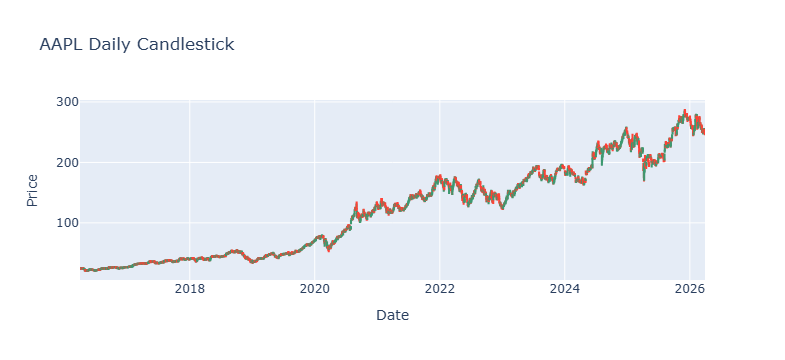

In [8]:
fig = plot_utils.create_candlestick_graph('AAPL', PROJECT_ROOT)
fig.show()

The candle stick plot is widely used in the industry. This plot is created using Plotly as a library and is an interactive plot allowing zoom in and zoom out functionality.  It is displaying open close, session-high and session-low prices for each trading day in the shape of the so-called candle-stick and also visualizes the whoole time series. With this plot I aim to show that ten-years window of data includes mutltiple scenatios and price development regimes - upturns and downturns, including the Covid crisis and other major events. I am not going to use this type plot extensively in this project besides showing that we have nice sets with varying market conditions. 

### 2. From this point on we deviate from the [Math for Developers Project](https://github.com/Kamend1/math_for_developers_final_project). Let's do some time series data exploration
Let's work with the returns dataframe created above

-  the rolling method in Pandas with parameters:
-  window = 21, we choose this for 21 trading days on average in a month
-  min_periods = 1, for the first 20 rows it gradually expands until it reaches 21
-  dropna(), because on the earliest day (first row), column 'std' remains NaN

In [9]:
stats = return_data['log_return'].rolling(window=21, min_periods=1).agg(['mean', 'std'])
return_data = pd.concat([return_data, stats], axis=1)

return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct,mean,std
Date,,,,,,,,,,,
2016-04-01,24.910591,24.912856,24.505191,24.636550,103496000,0.009175,0.009133,0.917523,0.913339,0.009133,NaN
2016-04-04,25.166513,25.408848,24.974004,25.007976,149424800,0.010274,0.010221,1.027363,1.022122,0.009677,0.000769
2016-04-05,24.869812,25.078175,24.781485,24.801869,106314800,-0.011790,-0.011860,-1.178953,-1.185958,0.002498,0.012446
2016-04-06,25.130270,25.134801,24.731664,24.964940,105616400,0.010473,0.010418,1.047286,1.041840,0.004478,0.010907
2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600,-0.021809,-0.022051,-2.180950,-2.205084,-0.000827,0.015165
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300,0.000596,0.000596,0.059642,0.059624,-0.002675,0.012966
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700,0.003894,0.003887,0.389444,0.388687,-0.003544,0.011777
2026-03-26,252.889999,257.000000,250.770004,252.119995,41796700,0.001069,0.001068,0.106882,0.106825,-0.003858,0.011549


#### 2.1 Outlier Detection Using Rolling Statistics (Dynamic Thresholds)

In this step, the objective is to identify abnormal return observations using time-varying statistical thresholds. Based on the rolling mean and standard deviation defined above, dynamic upper and lower bounds are constructed as a multiple of the standard deviation away from the mean. Specifically, a threshold of three standard deviations (N_SIGMAS = 3) is applied.

An observation is classified as an outlier if its return exceeds these dynamically adjusted bounds. Unlike static methods, this approach accounts for changes in market volatility over time, enabling more context-aware detection of extreme movements.

The resulting dataset is enriched with:

Rolling upper and lower thresholds reflecting local return behavior
A boolean indicator identifying statistically significant deviations

This method is particularly suitable for financial time series, where volatility is non-constant and extreme events should be evaluated relative to prevailing market conditions.

The presence of outliers is an expected and useful outcome, as it highlights periods of abnormal price movement. These observations serve as candidates for further analysis, including potential signal generation, rather than direct buy or sell indicators.

In [10]:
N_SIGMAS = 3

return_data = data_pipe.get_return_outliers(return_data, N_SIGMAS)
return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct,mean,std,upper,lower,outlier
Date,,,,,,,,,,,,,,
2016-04-04,25.166513,25.408848,24.974004,25.007976,149424800,0.010274,0.010221,1.027363,1.022122,0.009677,0.000769,0.011985,0.007370,False
2016-04-05,24.869812,25.078175,24.781485,24.801869,106314800,-0.011790,-0.011860,-1.178953,-1.185958,0.002498,0.012446,0.039837,-0.034840,False
2016-04-06,25.130270,25.134801,24.731664,24.964940,105616400,0.010473,0.010418,1.047286,1.041840,0.004478,0.010907,0.037198,-0.028241,False
2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600,-0.021809,-0.022051,-2.180950,-2.205084,-0.000827,0.015165,0.044667,-0.046322,False
2016-04-08,24.609369,24.860761,24.498393,24.665989,94326800,0.001106,0.001105,0.110559,0.110498,-0.000505,0.013587,0.040255,-0.041266,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300,0.000596,0.000596,0.059642,0.059624,-0.002675,0.012966,0.036224,-0.041574,False
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700,0.003894,0.003887,0.389444,0.388687,-0.003544,0.011777,0.031785,-0.038874,False
2026-03-26,252.889999,257.000000,250.770004,252.119995,41796700,0.001069,0.001068,0.106882,0.106825,-0.003858,0.011549,0.030789,-0.038505,False


Visualizing the data in this case provides very good information, all the scatter plot dots represent the presence of the outliers using the above definition:

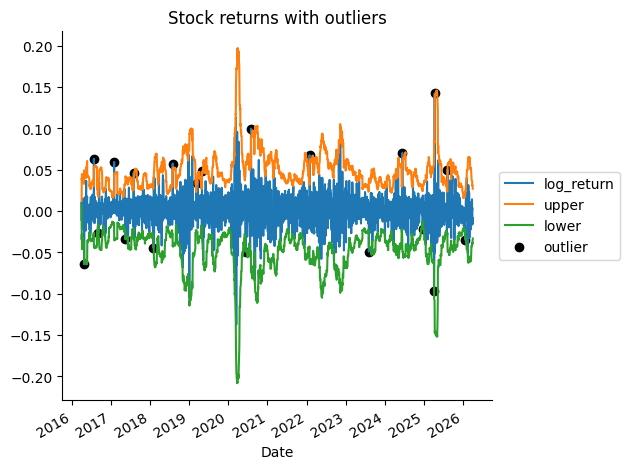

In [11]:
y_cols = ("log_return", "upper", "lower")
outlier_col = "outlier"
title = "Stock returns with outliers"

fig, ax = plot_utils.plot_returns_outliers(
    return_data,
    y_cols,
    outlier_col,
    title
)

#### 2.2 Outlier Detection Using Hampel Filter (Robust Method)

In addition to the standard deviation-based approach, a Hampel filter can be applied to detect outliers in a more robust manner. Unlike methods relying on the mean and standard deviation as above, the Hampel filter, as a statistical method, uses the median and the median absolute deviation (MAD) within the rolling window to identify extreme observations.

This makes the method less sensitive to the influence of existing outliers, which can distort the mean and inflate the standard deviation. As a result, the Hampel filter provides a more stable and reliable identification of abnormal returns, particularly in financial time series where heavy tails and volatility clustering are common.

Using a rolling window of 21 trading days, the filter evaluates each observation relative to the local median behavior. Observations that deviate significantly from this median-based threshold are flagged as outliers.

The key advantages of this approach include:

Robustness to extreme values, as the median is less affected by large deviations than the mean
Reduced distortion from volatility spikes and clustered outliers
More consistent detection of anomalies in non-normally distributed return series

This method is particularly useful as a complement to standard deviation-based approaches, allowing for comparison between parametric (mean-based) and robust (median-based) outlier detection techniques. Such a comparison provides a more comprehensive understanding of extreme return behavior and improves the reliability of downstream analysis.

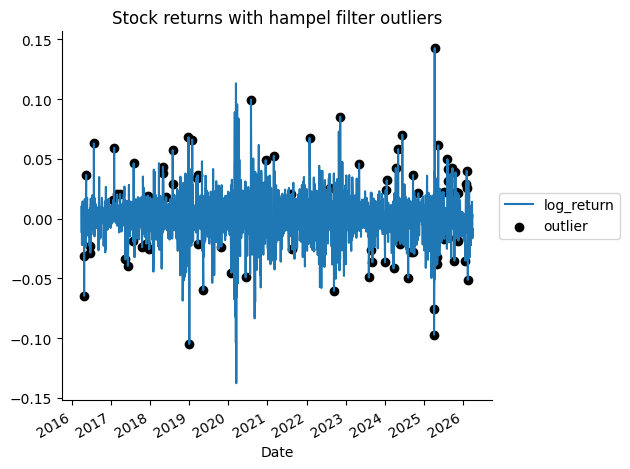

In [12]:
hampel_detector = HampelFilter(window_length=21, return_bool=True)
return_data["outlier_rtn"] = hampel_detector.fit_transform(return_data["log_return"])

y_cols = ("log_return", )
outlier_col = "outlier_rtn"
title = "Stock returns with hampel filter outliers"

fig, ax = plot_utils.plot_returns_outliers(
    return_data,
    y_cols,
    outlier_col,
    title
)

Providing the same visualization will show that the number of black dots is higher when introducing the Hampel filter. I.e. we can hope to identify and perform hypothesis testing to validate possible buy and sell signals in this time series, which is encouraging. 

#### 2.3 Regime Identification Using the Hurst Exponent

In this step, the objective is to characterize the underlying behavior of the return series by estimating its degree of persistence over time. For this purpose, the Hurst Exponent ($H$) is used as a statistical measure of long-term memory in the time series.

The Hurst Exponent captures the tendency of a series to either trend, mean-revert, or behave randomly. It is closely related to the autocorrelation structure of the data and reflects how the variability of the series evolves over time.

The value of $H$ lies in the interval $(0, 1)$ and can be interpreted as follows:

- **$H < 0.5$ — Mean-Reverting (Anti-persistent behavior)**  
  Price movements tend to reverse direction. Positive returns are more likely to be followed by negative returns, and vice versa. This regime is typically associated with mean-reversion strategies.

- **$H \approx 0.5$ — Random Walk**  
  The series behaves similarly to a Geometric Brownian Motion process, where past movements do not provide predictive power for future returns. This aligns with the weak form of the Efficient Market Hypothesis.

- **$H > 0.5$ — Trending (Persistent behavior)**  
  Price movements tend to continue in the same direction. Positive returns are more likely to be followed by positive returns. This regime is often associated with momentum-based strategies.

By estimating the Hurst Exponent for the return series, we gain insight into the dominant regime governing the asset’s behavior. This provides a useful context for interpreting previously identified outliers and supports the selection of appropriate downstream strategies.

In [13]:
for lag in [20, 100, 250, 500, 1000]:
    hurst_exp = ts_utils.get_hurst_exponent(return_data["Close"].values, lag)
    print(f"Hurst exponent with {lag} lags: {hurst_exp:.4f}")


Hurst exponent with 20 lags: 0.4468
Hurst exponent with 100 lags: 0.4535
Hurst exponent with 250 lags: 0.3637
Hurst exponent with 500 lags: 0.3159
Hurst exponent with 1000 lags: 0.2230


##### Interpretation of Hurst Exponent Results

The estimated Hurst Exponent values across different lag lengths are as follows:

- 20 lags: 0.4468  
- 100 lags: 0.4535  
- 250 lags: 0.3637  
- 500 lags: 0.3159  
- 1000 lags: 0.2230  

Across all lag specifications, the Hurst Exponent remains **consistently below 0.5**, indicating that the return series exhibits **mean-reverting (anti-persistent) behavior** rather than trending dynamics.

A key observation is the **declining trend in $H$ as the lag length increases**. This suggests that:
- At shorter horizons, the series is closer to a random walk but still slightly mean-reverting  
- At longer horizons, mean reversion becomes more pronounced  
- There is **no evidence of persistent (trend-following) behavior** in the data  

**Implications for the Project:**

These results have direct consequences for the overall analytical framework:

- **Validation of Outlier Context**  
  The previously identified outliers are likely to represent **temporary dislocations** rather than the start of sustained trends. This aligns with a mean-reverting market structure.

- **Strategy Alignment**  
  A mean-reverting regime supports:
  - Reversal-based strategies  
  - Statistical arbitrage approaches  
  - Short-term correction trades following extreme movements  

  Conversely, momentum-based strategies are less likely to be effective in this context.

- **Consistency with Robust Methods**  
  The presence of mean reversion strengthens the case for using robust outlier detection methods (e.g., Hampel filter), as extreme deviations are more likely to revert and should be detected reliably without distortion.

- **Time Horizon Sensitivity**  
  The decreasing Hurst values at higher lags indicate that **mean reversion strengthens over longer horizons**, suggesting that holding periods and signal horizons should be carefully aligned with this behavior.

##### Key Takeaway

The return series does not exhibit trending characteristics. Instead, it shows **increasingly strong mean-reverting behavior as the observation window expands**. This reinforces a potential framework focused on identifying and exploiting temporary deviations, rather than attempting to capture sustained directional trends.

#### 2.4 Q-Q Plot Analysis and Interpretation

The Q-Q (quantile-quantile) plot compares the empirical distribution of log returns to a theoretical normal distribution. If the returns were normally distributed, the observations would align closely along the reference line.

In the observed plot, an S-shaped pattern is evident, particularly in the tails of the distribution. While the central quantiles remain relatively aligned with the normal reference line, the tails deviate significantly. This indicates that extreme positive and negative returns occur more frequently than would be expected under a normal distribution, confirming the presence of **fat tails**.

The S-shaped deviation from normality is not just a statistical artifact—it reflects structural characteristics of financial markets:

- Return distributions are **leptokurtic**, with a higher probability of extreme events  
- Large price movements are more common than predicted by Gaussian models  
- The assumption of normally distributed returns is therefore insufficient for capturing real market behavior  

##### Implications for the Project

This finding directly supports the broader analytical framework of the project:

- **Signal Identification Potential**  
  The systematic deviation from normality suggests that extreme return events are not purely random. Instead, they may reflect underlying inefficiencies such as overreaction or liquidity imbalances, creating opportunities to identify and exploit return- and price-based signals.

- **Justification for Outlier Detection**  
  The presence of fat tails validates the use of both standard deviation-based and robust outlier detection methods. These approaches allow for the systematic identification of extreme observations that may carry informational value.

- **Need for Robust Methods**  
  Since mean and standard deviation are sensitive to extreme values, the observed distributional properties reinforce the importance of robust techniques (e.g., Hampel filter) for more stable anomaly detection.

- **Integration with Regime Analysis**  
  Combined with the Hurst Exponent results indicating mean-reverting behavior, extreme deviations are more likely to represent temporary dislocations rather than persistent trends, further strengthening their relevance as potential trading signals.

**Key Takeaway** - The Q-Q plot confirms that return distributions exhibit non-normal, fat-tailed behavior with a clear S-shaped deviation. This provides empirical support for the project’s core premise: extreme return events can be systematically identified and may serve as actionable signals within a structured analytical framework.

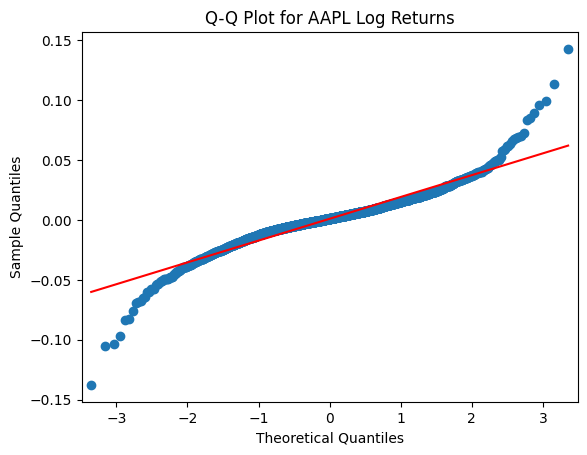

In [14]:
title = "Q-Q Plot for AAPL Log Returns"

fig = plot_utils.create_q_q_plot(return_data, title)
plt.show()

#### 2.5 Descriptive Statistics and Distribution Analysis

In this step, the objective is to quantify the statistical properties of the return series and assess its distributional characteristics.

First, key summary statistics are computed, including the mean, variance, and standard deviation of log returns over the full observation period. These metrics provide a baseline understanding of average return behavior and overall volatility.

A histogram of daily log returns is then constructed to visualize the empirical distribution relative to the estimated mean and standard deviation. This allows for an intuitive assessment of symmetry, dispersion, and the presence of extreme observations.

In addition, a full set of descriptive statistics is evaluated, including:
- Central tendency measures (mean and median)  
- Dispersion (standard deviation)  
- Distribution shape (skewness and kurtosis)  
- Range (minimum and maximum values)  

Finally, the Jarque-Bera test is applied to formally assess whether the return distribution conforms to normality. This test jointly evaluates skewness and kurtosis relative to a normal benchmark.

This step provides a comprehensive statistical characterization of the return series, forming the foundation for subsequent analysis.

Mean log return in observation period: 0.0009126577222088359,
Variance of log returns in observation period: 0.00033132527727708556,
Standard deviation of log returns in observation period: 0.01820234263157041


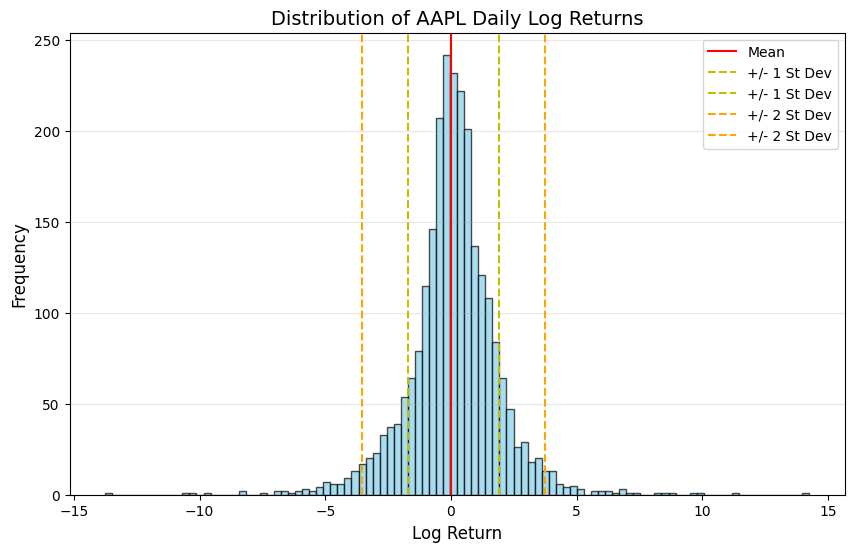

In [15]:
mean = return_data["log_return"].mean()
variance = return_data["log_return"].var()
st_dev = return_data["log_return"].std()

print(f"Mean log return in observation period: {mean},\n"
      f"Variance of log returns in observation period: {variance},\n"
      f"Standard deviation of log returns in observation period: {st_dev}")

ticker = 'AAPL'
fig = plot_utils.create_histogram_distribution_daily_log_returns(return_data, ticker, mean, st_dev)
plt.show()

In [16]:
jb_test = scs.jarque_bera(return_data["log_return"].values)

print("---------- Descriptive Statistics ----------")
print("Range of dates:", min(return_data.index.date), "-", max(return_data.index.date))
print("Number of observations:", return_data.shape[0])
print(f"Mean: {return_data.log_return.mean():.4f}")
print(f"Median: {return_data.log_return.median():.4f}")
print(f"Min: {return_data.log_return.min():.4f}")
print(f"Max: {return_data.log_return.max():.4f}")
print(f"Standard Deviation: {return_data.log_return.std():.4f}")
print(f"Skewness: {return_data.log_return.skew():.4f}")
print(f"Kurtosis: {return_data.log_return.kurtosis():.4f}") 
print(f"Jarque-Bera statistic: {jb_test[0]:.2f} with p-value: {jb_test[1]:.2f}")

---------- Descriptive Statistics ----------
Range of dates: 2016-04-04 - 2026-03-30
Number of observations: 2512
Mean: 0.0009
Median: 0.0010
Min: -0.1377
Max: 0.1426
Standard Deviation: 0.0182
Skewness: -0.0777
Kurtosis: 6.7952
Jarque-Bera statistic: 4812.92 with p-value: 0.00


##### Interpretation of Results and Project Implications

The descriptive statistics reveal several important characteristics of the return series.

The mean and median are closely aligned (approximately 0.001), indicating no significant bias in central tendency and suggesting a relatively symmetric distribution around the average return. However, the range of returns is wide, with extreme values on both the negative and positive sides, highlighting the presence of large price movements.

The standard deviation of approximately 1.82% reflects the typical daily volatility, while the observed minimum and maximum values significantly exceed this range, reinforcing the presence of extreme observations.

Skewness is slightly negative (-0.0777), indicating a mild asymmetry with somewhat heavier downside moves. More importantly, kurtosis is substantially elevated (6.7952), confirming that the distribution is **leptokurtic**, with fat tails and a higher frequency of extreme events than a normal distribution would predict.

This is further validated by the Jarque-Bera test, which strongly rejects the null hypothesis of normality (p-value ≈ 0). This provides formal statistical evidence that the return distribution deviates significantly from the Gaussian assumption.

**Implications for the Project:**

- **Confirmation of Non-Normality**  
  The return series does not follow a normal distribution, reinforcing earlier findings from the Q-Q plot. This invalidates reliance on purely Gaussian-based assumptions.

- **Support for Outlier Detection Framework**  
  The presence of fat tails and extreme values confirms that outlier detection is not only relevant but essential. These extreme observations are structural features of the data.

- **Justification for Robust Methods**  
  Elevated kurtosis and non-normality strengthen the case for using robust techniques such as the Hampel filter, as mean and standard deviation are sensitive to extreme values.

- **Signal Generation Potential**  
  The magnitude and frequency of extreme returns suggest that large deviations may carry informational value, supporting the broader objective of identifying exploitable return- and price-based signals.

- **Risk Perspective**  
  The distribution implies that tail risk is materially higher than under normal assumptions, which must be considered in any downstream strategy design.

##### Key Takeaway

The return series exhibits low skewness but significant excess kurtosis and clear non-normality. Extreme events are not rare anomalies but inherent features of the data, reinforcing the project’s focus on detecting and leveraging such deviations within a structured analytical framework.

#### 2.6 Seasonality and Trend Analysis (Decomposition)

In this step, the objective is to decompose the return series into its underlying structural components in order to better understand its behavior over time.

Two decomposition approaches are applied:

- **Classical Additive Decomposition**  
  The series is split into three components:
  - **Trend**: long-term movement in the data  
  - **Seasonality**: repeating patterns over a fixed period (set to 252 trading days ≈ 1 year)  
  - **Residual**: remaining unexplained variation  

- **STL Decomposition (Seasonal-Trend decomposition using LOESS)**  
  A more flexible and robust method that:
  - Uses local regression (LOESS)  
  - Handles non-linear trends more effectively  
  - Is less sensitive to outliers and noise  

##### Why This Is Important

Decomposition allows us to observe whether the return series contains:
- A persistent **trend** component  
- Any **seasonal patterns** (e.g., yearly effects)  
- Or is dominated by **noise/random fluctuations**  

This is critical because:

- Many financial models assume **no deterministic trend in returns**  
- Seasonality, if present, could be exploited as a systematic signal  
- Identifying the residual structure helps validate earlier assumptions about randomness and stationarity  

##### What We Are Looking For

- Whether the **trend component is flat or drifting**  
- Whether there are **repeating seasonal patterns** across periods  
- Whether most variation is pushed into the **residual component**  

Consistency between classical and STL decomposition strengthens the reliability of the findings.

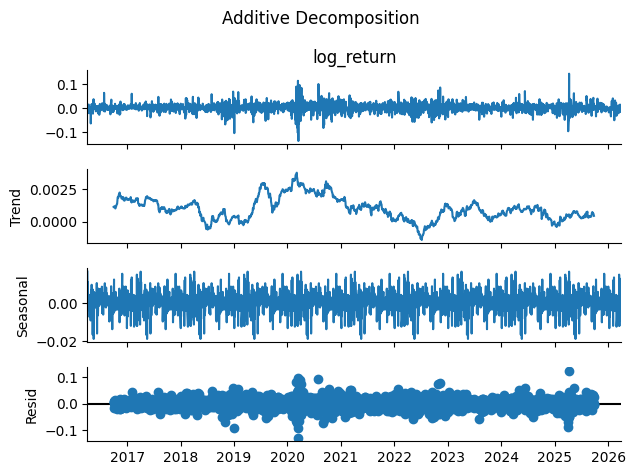

In [17]:
decomposition_results = seasonal_decompose(return_data["log_return"], 
                                           model="additive",
                                          period=252,)
                                            
(
    decomposition_results
    .plot()
    .suptitle("Additive Decomposition")
)

sns.despine()
plt.tight_layout()

Let us use the STL decomposition as a more robust method:

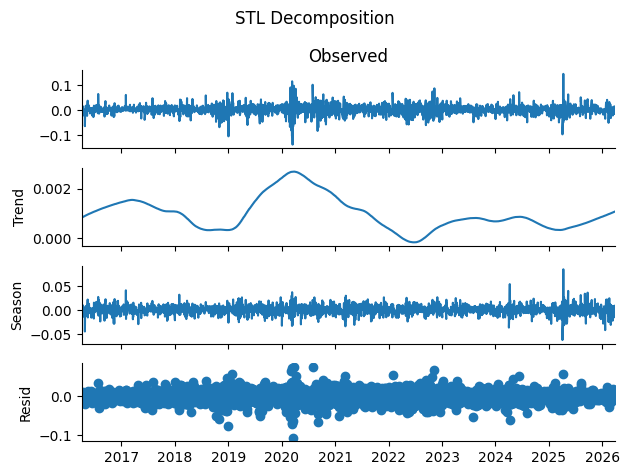

In [18]:
stl_decomposition = STL(return_data[["log_return"]], period=252).fit()
stl_decomposition.plot() \
                 .suptitle("STL Decomposition")

sns.despine()
plt.tight_layout()

##### Seasonal and STL Decomposition Outcome

The STL decomposition produces a visibly cleaner separation of components compared to classical seasonal decomposition. The trend component appears smoother and more stable, indicating that STL is more effective at extracting the underlying direction of the series.

However, despite this improvement, the majority of the signal remains dominated by noise. The seasonal component shows weak and potentially unstable patterns, suggesting limited or non-persistent cyclical behavior in the data. The residual component retains significant variance, reinforcing the idea that much of the movement is not explained by trend or seasonality.

Overall, while STL improves interpretability and reduces visual clutter in the trend, the decomposition confirms that the dataset—particularly log returns—contains a high level of randomness with minimal exploitable structure.

##### Interpretation of Results and Project Implications

The decomposition results for the data obtained for any of the 30 tickers show that the log return series lacks a strong trend component and does not exhibit stable or economically meaningful seasonality.

- The **trend component** is generally flat and unstable, indicating no persistent directional movement in returns over time.  
- The **seasonal component**, even when forced at a yearly frequency (252 trading days), does not display consistent or exploitable patterns.  
- The majority of the variation is captured in the **residual component**, suggesting that returns are largely driven by irregular, high-frequency fluctuations.

The STL decomposition further reinforces these findings, as it provides a smoother and more robust separation of components while still showing minimal trend and weak or negligible seasonality.

##### Implications for the Project

- **No Reliable Seasonal Signals**  
  The absence of strong seasonality implies that calendar-based strategies are unlikely to add value in this context.

- **No Deterministic Trend in Returns**  
  This aligns with financial theory, where returns (unlike prices) are not expected to trend over time.

- **Residual Dominance = Noise + Shocks**  
  Most of the variation is in the residual component, which supports the idea that returns are driven by:
  - Market shocks  
  - Information flow  
  - Short-term inefficiencies  

- **Consistency with Previous Findings**  
  These results align with:
  - Weak autocorrelation (limited linear predictability)  
  - Stationarity (stable statistical properties)  
  - Mean-reverting tendencies (from Hurst exponent)  

- **Strategic Direction**  
  Since no trend or seasonality is present, the project should focus on:
  - Outlier detection  
  - Mean-reversion signals  
  - Distributional anomalies  

**Key Takeaway** - The return series does not exhibit a meaningful trend or seasonal structure. Instead, it is dominated by irregular fluctuations, reinforcing the view that exploitable signals are more likely to arise from extreme events and local deviations rather than systematic patterns over time.

#### 2.7 Stationarity Testing (ADF and KPSS)

In this step, the objective is to assess whether the return series is **stationary**, which is a fundamental assumption underlying most time series models and statistical inference techniques used throughout the project.

A stationary time series is characterized by:
- Constant mean over time  
- Constant variance (no structural changes in volatility)  
- Stable autocorrelation structure  

Stationarity is critical because many analytical tools—such as rolling statistics, outlier detection methods, and regime classification—implicitly assume that the statistical properties of the series do not change over time. If this assumption is violated, model outputs and interpretations may become unreliable or misleading.

To evaluate stationarity, two complementary statistical tests are applied:

- **Augmented Dickey-Fuller (ADF) Test**  
  The ADF test evaluates the null hypothesis that the series contains a unit root (i.e., is non-stationary).  
  - Null hypothesis: the series is non-stationary  
  - Rejection (low p-value): evidence of stationarity  

- **KPSS Test (Kwiatkowski–Phillips–Schmidt–Shin)**  
  The KPSS test takes the opposite perspective.  
  - Null hypothesis: the series is stationary  
  - Rejection (low p-value): evidence of non-stationarity  

By combining both tests, a more robust conclusion can be reached:
- If ADF rejects and KPSS does not reject → strong evidence of stationarity  
- If both fail → inconclusive  
- If both reject → structural instability or model misspecification  

##### What We Are Looking For

The goal is to determine whether the log return series satisfies stationarity conditions:

- For financial returns, stationarity is generally expected  
- If confirmed, it validates the use of:
  - Rolling statistical measures  
  - Outlier detection frameworks  
  - Distributional analysis and signal generation  

If the series were found to be non-stationary, it would imply:
- Presence of trends or structural breaks  
- Instability in variance or mean  
- Reduced reliability of statistical thresholds and models  

##### Why This Matters for the Project

- **Model Validity**  
  Stationarity ensures that statistical estimates (mean, variance) are meaningful and stable over time.

- **Consistency of Outlier Detection**  
  Threshold-based methods rely on stable distributional properties; non-stationarity would distort these thresholds.

- **Interpretability of Signals**  
  Signals derived from a non-stationary process may reflect regime shifts rather than exploitable patterns.

- **Foundation for Time Series Analysis**  
  Confirming stationarity provides confidence that the analytical framework is built on statistically sound assumptions.

**Key Takeaway** - Stationarity is a prerequisite for reliable time series analysis. By applying both ADF and KPSS tests, the project ensures that the return series exhibits stable statistical properties, supporting the validity of the downstream modeling and signal extraction framework.

In [19]:
ts_utils.adf_test(return_data["log_return"])

Test Statistic           -1.628413e+01
p-value                   3.388975e-29
# of Lags Used            8.000000e+00
# of Observations Used    2.503000e+03
Critical Value (1%)      -3.432965e+00
Critical Value (5%)      -2.862695e+00
Critical Value (10%)     -2.567385e+00
dtype: float64

##### Augmented Dickey-Fuller (ADF) Test Outcome

The Augmented Dickey-Fuller test strongly rejects the null hypothesis of non-stationarity.

The test statistic (-16.28) is significantly lower than all critical values at the 1%, 5%, and 10% levels. Additionally, the p-value (~3.39e-29) is effectively zero, providing overwhelming statistical evidence against the null hypothesis.

This indicates that the log return series is stationary, meaning its statistical properties such as mean and variance remain stable over time.

From a practical standpoint, this confirms that no differencing is required before applying time series models. The series is already suitable for modeling approaches that assume stationarity, such as ARMA or GARCH.

Overall, the result aligns with expectations for financial return series, which are typically stationary but exhibit high levels of noise and volatility.

##### KPSS Test Explanation and Outcome

The Kwiatkowski–Phillips–Schmidt–Shin (KPSS) test is a statistical method used to determine whether a time series is stationary. Unlike the Augmented Dickey-Fuller (ADF) test, the KPSS test assumes stationarity as the null hypothesis.

- **Null Hypothesis (H₀):** The time series is stationary (around a constant or trend)
- **Alternative Hypothesis (H₁):** The time series is non-stationary

The test evaluates whether the series exhibits a stable mean (or deterministic trend) over time, or whether it contains a unit root component that causes it to drift.

In [20]:
ts_utils.kpss_test(return_data["log_return"])

D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\src\signal_testing_utils\time_series_utils.py:70: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Test Statistic           0.092073
p-value                  0.100000
# of Lags                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

##### KPSS Test Results Interpretation

The test statistic (0.092) is significantly lower than all provided critical values at the 10%, 5%, 2.5%, and 1% significance levels. Additionally, the p-value (0.10) is relatively high, indicating that there is insufficient evidence to reject the null hypothesis.

This means that the log return series can be considered stationary around a constant mean.


##### Final Conclusion

The KPSS test confirms that the series does not exhibit non-stationary behavior. When combined with the ADF test results, which also reject non-stationarity, there is strong and consistent evidence that the log return series is stationary.

From a modeling perspective, this implies that the series is already in a suitable form for time series models that require stationarity, and no differencing is necessary.

#### 2.8 Autocorrelation Analysis (ACF and PACF)

In this step, the objective is to examine the **serial dependence structure** of the return series by analyzing its autocorrelation properties.

Two key tools are used:

- **Autocorrelation Function (ACF)**  
  Measures the correlation between the time series and its lagged values across multiple lags. It captures both direct and indirect relationships over time.

- **Partial Autocorrelation Function (PACF)**  
  Measures the direct correlation between the series and its lagged values, controlling for the effects of intermediate lags. It isolates the incremental contribution of each lag.

The plots are generated up to 40 lags, with confidence intervals defined at the **1% significance level**. Any spikes outside the confidence bands indicate statistically significant autocorrelation at that lag.


##### Why This Is Important

Autocorrelation analysis helps determine whether past returns contain predictive information about future returns.

- If autocorrelations are insignificant → returns behave like a random process  
- If significant autocorrelations exist → potential predictability and structure in the data  

This directly relates to market efficiency and the feasibility of constructing return-based signals.


##### What We Are Looking For

- Whether most autocorrelations lie within the confidence bands  
- Presence of significant spikes at specific lags  
- Patterns such as decay or clustering in autocorrelation  

These observations help assess:
- Market efficiency (random vs structured behavior)  
- Suitability of time series models  
- Potential for signal generation based on lagged returns  

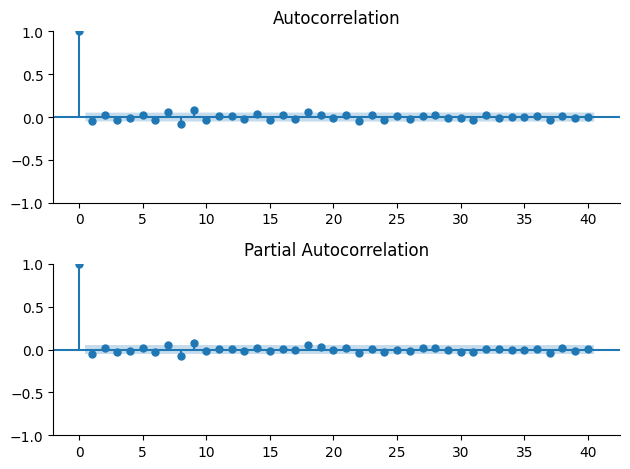

In [21]:
N_LAGS = 40
SIGNIFICANCE_LEVEL = 0.01

fig, ax = plt.subplots(2, 1)
plot_acf(return_data["log_return"], ax=ax[0], lags=N_LAGS, 
         alpha=SIGNIFICANCE_LEVEL)
plot_pacf(return_data["log_return"], ax=ax[1], lags=N_LAGS, 
          alpha=SIGNIFICANCE_LEVEL)

sns.despine()
plt.tight_layout()

##### Interpretation of Results and Project Implications

The ACF and PACF plots typically show that most autocorrelation coefficients lie within the confidence intervals, indicating that **daily log returns exhibit little to no significant serial correlation**.

This suggests that:
- The return series behaves close to a **random process** in terms of linear dependence  
- Past returns have **limited predictive power** for future returns  
- There is no strong evidence of a persistent linear structure that could be easily exploited  

However, a few isolated spikes appear outside the confidence bands for **any of the chosen tickers**. These are common in financial time series and may reflect:
- Short-term market microstructure effects  
- Noise rather than stable predictive relationships  

##### Implications for the Project

- **Limited Linear Predictability**  
  The lack of strong autocorrelation implies that simple lag-based strategies are unlikely to generate consistent returns.

- **Focus on Nonlinear and Distributional Features**  
  Since linear dependence is weak, the project’s focus on:
  - Outlier detection  
  - Distributional anomalies  
  - Regime behavior (Hurst exponent)  
  becomes more relevant.

- **Consistency with Market Efficiency**  
  The results are broadly consistent with the weak form of the Efficient Market Hypothesis, where past returns do not systematically predict future returns.

- **Signal Strategy Direction**  
  Instead of relying on autocorrelation, signal generation should be based on:
  - Extreme events (outliers)  
  - Mean-reversion dynamics  
  - Structural deviations from normality  

**Key Takeaway** - The return series shows minimal linear autocorrelation, indicating that predictability is not driven by simple lag relationships. This reinforces the project’s emphasis on identifying signals through extreme events and distributional properties rather than traditional time series dependence.

#### 2.9 Volatility Clustering

In this step, the objective is to investigate whether volatility in the return series exhibits temporal dependence, a phenomenon commonly referred to as **volatility clustering**.

To examine this, three complementary approaches are applied:

- **Lagged Volatility Scatterplot**  
  Squared returns are used as a proxy for volatility. A scatterplot of current volatility ($vol_t$) against its lagged value ($vol_{t-1}$) is constructed, along with a fitted regression line. This allows for direct visualization of the relationship between consecutive volatility observations.

- **Time Series Visualization**  
  Both raw log returns and absolute returns are plotted. While returns themselves may appear random, absolute returns highlight periods of elevated and subdued volatility, making clustering visually apparent.

- **Autocorrelation of Squared Returns**  
  The autocorrelation function (ACF) of squared returns is analyzed to detect statistically significant dependence in volatility over multiple lags.

##### Why This Is Important

Volatility clustering is a well-documented property of financial time series. Its presence implies that:

- Variance is **time-varying (heteroskedastic)** rather than constant  
- Risk is **persistent and predictable to some extent**  
- Market behavior cannot be fully described by simple i.i.d. assumptions  

Understanding volatility dynamics is critical for:
- Risk modeling  
- Outlier interpretation  
- Signal generation based on extreme events  

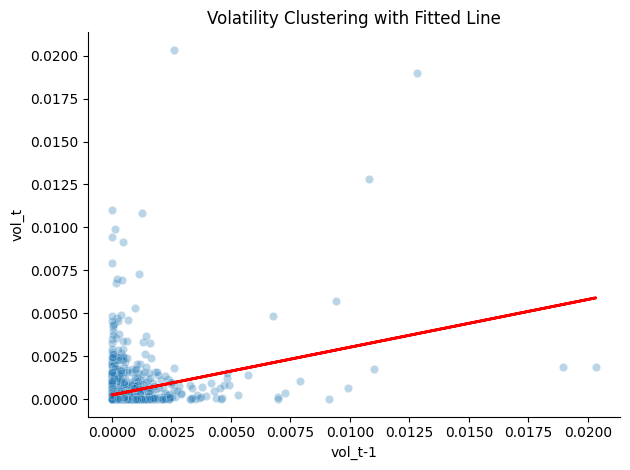

In [22]:
df_vol = pd.DataFrame()

df_vol["vol_t"] = return_data["log_return"]**2
df_vol["vol_t-1"] = df_vol["vol_t"].shift(1)

df_vol = df_vol.dropna()

sns.scatterplot(x="vol_t-1", y="vol_t", data=df_vol, alpha=0.3)

x = df_vol["vol_t-1"]
y = df_vol["vol_t"]

m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color="red", linewidth=2)

plt.title("Volatility Clustering with Fitted Line")
sns.despine()
plt.tight_layout()
plt.show()

##### Volatility Clustering – Scatterplot Interpretation

The fitted regression line exhibits a clear upward slope, indicating a positive relationship between lagged and current volatility.

This implies that periods of high volatility tend to be followed by further high volatility, while periods of low volatility are likely to be followed by continued calm conditions. In other words, volatility is persistent over time rather than randomly distributed.

Although the scatterplot is heavily concentrated near the origin—reflecting the fact that most daily returns are small—the upward trend in the fitted line reveals an underlying dependency structure. This pattern is consistent with the well-established phenomenon of volatility clustering in financial time series.

Overall, the result confirms that while returns themselves may appear random, their magnitude (volatility) exhibits temporal dependence.

##### Time series visualization

Both raw log returns and absolute returns are plotted. While returns themselves may appear random, absolute returns highlight periods of elevated and subdued volatility, making clustering visually apparent.

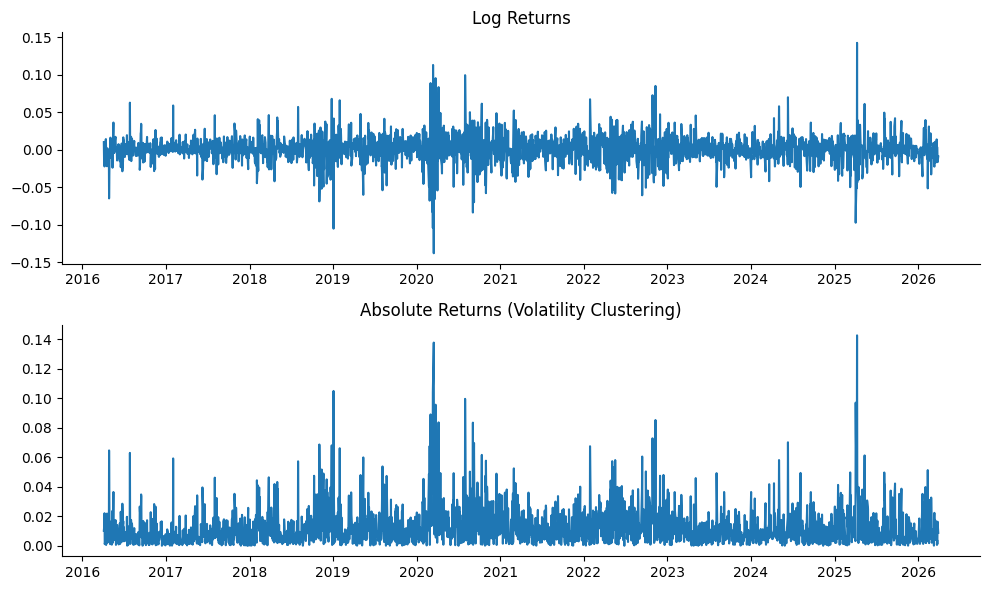

In [23]:
returns = return_data['log_return']

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot(returns)
ax[0].set_title("Log Returns")

ax[1].plot(returns.abs())
ax[1].set_title("Absolute Returns (Volatility Clustering)")

sns.despine()
plt.tight_layout()
plt.show()

##### Autocorrelation of Squared Returns
The autocorrelation function (ACF) of squared returns is analyzed to detect statistically significant dependence in volatility over multiple lags.

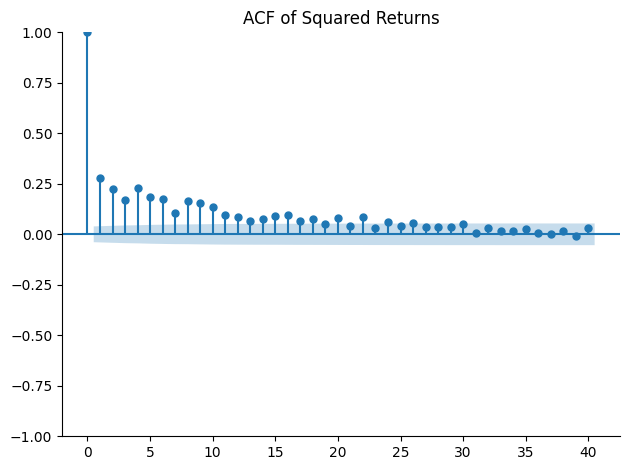

In [24]:
plot_acf(returns**2, lags=40)
plt.title("ACF of Squared Returns")
sns.despine()
plt.tight_layout()
plt.show()

##### Interpretation of Results and Project Implications

The results across all three approaches consistently indicate the presence of volatility clustering.

The scatterplot shows a clear positive relationship between lagged and current volatility, as evidenced by the upward-sloping fitted regression line. This confirms that periods of high volatility tend to be followed by further high volatility, and similarly for low-volatility periods.

The time series visualization reinforces this finding. While log returns appear largely random, the absolute returns reveal distinct clusters of high and low volatility, indicating that large movements tend to occur in bursts rather than in isolation.

The autocorrelation function of squared returns further supports this conclusion, with statistically significant lags indicating persistence in volatility over time.

##### Implications for the Project

- **Presence of Heteroskedasticity**  
  The return series does not have constant variance, which invalidates standard assumptions of homoskedasticity and reinforces the need for time-varying analysis.

- **Nonlinear Dependence Structure**  
  While earlier analysis showed little linear autocorrelation in returns, the presence of autocorrelation in squared returns indicates that dependence exists in the magnitude of returns rather than their direction.

- **Support for Outlier-Based Framework**  
  Volatility clustering explains the occurrence of extreme return events and supports the project’s focus on identifying and analyzing such deviations.

- **Alignment with Distributional Findings**  
  The presence of clustering is consistent with previously observed fat tails and non-normality in the return distribution.

**Key Takeaway** - Although returns themselves exhibit limited predictability, their volatility is clearly persistent over time. This confirms that meaningful structure exists in the magnitude of returns, reinforcing the project’s focus on exploiting extreme events and volatility-driven dynamics rather than directional predictability.

### 3. Create the data outcomes to be used downstream in the project

The following three cells will establish the price and return datasets encompassing the period defined by the star and end dates at the start of the notebook. Downstream I will use these datasets as static and the files will be located in Google Cloud Storage.

In [25]:
returns_df = data_pipe.build_returns_df(tickers, PROJECT_ROOT)
returns_df.to_csv(DATA_DIR / "stock_returns_static_dataset.csv")
returns_df

,AAPL,GOOG,MSFT,NVDA,JPM,BAC,F,UPS,WMT,TGT,...,CVX,CAT,DE,LMT,AMD,INTC,ORCL,CRM,CB,PG
Date,,,,,,,,,,,,,,,,,,,,,
2016-04-01,0.009133,0.006636,0.006137,0.014489,0.010916,0.002954,-0.030078,-0.004943,0.008288,0.005817,...,-0.012022,0.003260,-0.006385,0.007243,-0.007042,0.003087,0.006092,0.025409,0.014167,0.014713
2016-04-04,0.010221,-0.006180,-0.002523,-0.009729,-0.003877,-0.003694,-0.023167,-0.000667,0.000579,-0.005574,...,-0.008845,-0.014031,-0.007874,0.004561,0.000000,-0.013965,-0.002189,-0.000528,-0.002154,-0.003838
2016-04-05,-0.011860,-0.010101,-0.015820,-0.001397,-0.014291,-0.023971,-0.002346,-0.009195,-0.006679,-0.002433,...,-0.008168,-0.006360,0.002238,0.006626,-0.025046,-0.003130,-0.013236,-0.014774,-0.022136,-0.000601
2016-04-06,0.010418,0.010637,0.010212,0.001397,0.007681,0.006047,0.003907,0.007191,0.005811,0.000852,...,0.023147,-0.000266,0.003543,0.004466,0.014389,0.005627,0.005414,0.013319,0.010458,0.007786
2016-04-07,-0.022051,-0.007281,-0.012046,-0.010389,-0.025662,-0.032162,-0.023679,-0.006518,-0.011948,-0.007329,...,-0.000528,-0.014057,-0.002098,-0.000662,-0.058840,-0.016659,-0.019327,-0.003446,-0.013175,-0.006824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-24,0.000596,-0.033392,-0.027154,-0.002508,0.008552,0.012963,0.006780,0.007853,0.010957,0.008577,...,0.007670,0.021054,0.024288,-0.009915,0.013185,0.001136,-0.048113,-0.064327,-0.002331,-0.005781
2026-03-25,0.003887,0.001348,-0.004571,0.019668,0.010275,0.012592,-0.014462,-0.000711,0.008241,0.003875,...,-0.007962,0.003357,-0.008665,0.022733,0.070041,0.068418,-0.007301,-0.005809,-0.007398,0.005295
2026-03-26,0.001068,-0.031037,-0.013759,-0.042530,-0.012809,-0.010517,-0.006016,-0.008884,-0.007177,0.005399,...,0.012787,-0.022290,0.005521,0.005002,-0.077862,-0.067510,-0.022229,0.020022,0.003398,-0.010477


In [26]:
close_price_df = data_pipe.build_close_price_df(tickers, PROJECT_ROOT)
close_price_df.to_csv(DATA_DIR / "stock_close_prices_static_dataset.csv")
close_price_df

,AAPL,GOOG,MSFT,NVDA,JPM,BAC,F,UPS,WMT,TGT,...,CVX,CAT,DE,LMT,AMD,INTC,ORCL,CRM,CB,PG
Date,,,,,,,,,,,,,,,,,,,,,
2016-03-31,24.684109,36.944187,48.596268,0.872227,45.053688,10.839224,7.976823,72.731972,19.129591,61.035221,...,62.372246,60.400520,65.485657,169.963104,2.850000,25.791693,35.098404,72.761749,99.815353,62.620205
2016-04-01,24.910591,37.190170,48.895439,0.884956,45.548187,10.871292,7.740472,72.373375,19.288801,61.391293,...,61.626926,60.597775,65.068886,171.198563,2.830000,25.871426,35.312893,74.634247,101.239510,63.548367
2016-04-04,25.166513,36.961052,48.772255,0.876388,45.371918,10.831209,7.563211,72.325096,19.299973,61.050068,...,61.084263,59.753437,64.558525,171.981216,2.830000,25.512644,35.235676,74.594826,101.021706,63.304939
2016-04-05,24.869812,36.589603,48.006741,0.875164,44.728123,10.574658,7.545485,71.663086,19.171490,60.901718,...,60.587387,59.374626,64.703148,173.124542,2.760000,25.432920,34.772377,73.500893,98.810104,63.266884
2016-04-06,25.130270,36.980885,48.499481,0.876388,45.073013,10.638797,7.575027,72.180283,19.283213,60.953648,...,62.006142,59.358860,64.932777,173.899506,2.800000,25.576433,34.961132,74.486420,99.848885,63.761398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-24,251.639999,289.200012,372.739990,175.199997,290.911194,48.139999,11.840000,98.440002,122.050003,115.919998,...,206.789993,715.268250,581.319763,610.169983,205.369995,44.060001,146.578064,182.563416,325.609985,143.160004
2026-03-25,252.619995,289.589996,371.040009,178.679993,293.915833,48.750000,11.670000,98.370003,123.059998,116.370003,...,205.149994,717.673645,576.304382,624.200012,220.270004,47.180000,145.511795,181.506058,323.209991,143.919998
2026-03-26,252.889999,280.739990,365.970001,171.240005,290.174957,48.240002,11.600000,97.500000,122.180000,117.000000,...,207.789993,701.853821,579.495117,627.330017,203.770004,44.099998,142.312958,185.176880,324.309998,142.419998


In [27]:
open_price_df = data_pipe.build_open_price_df(tickers, PROJECT_ROOT)
open_price_df.to_csv(DATA_DIR / "stock_open_prices_static_dataset.csv")
open_price_df

,AAPL,GOOG,MSFT,NVDA,JPM,BAC,F,UPS,WMT,TGT,...,CVX,CAT,DE,LMT,AMD,INTC,ORCL,CRM,CB,PG
Date,,,,,,,,,,,,,,,,,,,,,
2016-03-31,24.849440,37.157437,48.349900,0.879326,45.228668,10.815172,7.882283,72.856100,19.202211,61.198418,...,62.234949,60.211129,68.198988,170.845527,2.840000,25.935202,35.287152,72.988417,100.167198,62.954952
2016-04-01,24.636550,36.629277,48.437896,0.866841,44.901521,10.799137,7.846829,72.352688,18.998323,60.649494,...,61.254262,59.698160,64.864750,168.781484,2.790000,25.727917,34.901081,72.318244,99.471902,62.384366
2016-04-04,25.007976,37.197609,48.772255,0.892300,45.555856,10.855261,7.746382,72.435434,19.272042,61.487727,...,61.744599,60.416309,64.881741,171.282945,2.830000,25.672098,35.304313,74.752507,103.040635,63.639687
2016-04-05,24.801869,36.599524,48.561068,0.868555,44.904398,10.662848,7.521849,71.994096,19.280420,60.938810,...,60.803141,59.437759,64.133265,171.904494,2.760000,25.424948,35.046918,73.796547,100.519072,63.266884
2016-04-06,24.964940,36.488925,47.830767,0.864148,44.590169,10.582676,7.533665,71.732042,19.188249,60.864635,...,60.901227,59.595597,64.745657,172.886627,2.750000,25.488731,34.660854,73.678285,98.843606,63.251674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-24,250.350006,296.209991,382.359985,174.830002,284.712934,47.049999,11.680000,97.050003,120.629997,113.820000,...,206.050003,692.481614,558.915261,612.950012,201.389999,43.540001,152.467498,191.660659,326.089996,143.330002
2026-03-25,254.100006,292.149994,376.920013,177.100006,292.652280,48.520000,11.950000,99.279999,122.809998,117.500000,...,206.000000,725.868066,586.863525,612.500000,211.509995,45.849998,148.710614,185.236718,326.369995,143.740005
2026-03-26,252.119995,286.190002,370.820007,176.070007,291.090256,48.709999,11.560000,97.889999,123.610001,115.879997,...,206.029999,708.720752,572.286221,619.799988,217.979996,46.299999,143.389201,180.728000,323.660004,143.690002


### 4. Transition to notebook 1_2
#### From Exploratory Analysis to Signal Construction

The current notebook establishes a comprehensive empirical understanding of the statistical and structural properties of stock return series. Through a combination of distributional analysis, stationarity testing, autocorrelation assessment, regime identification, and volatility clustering diagnostics, the analysis consistently demonstrates that financial returns exhibit non-normality, time-varying volatility, and limited linear predictability.

These findings provide a validated foundation for moving beyond descriptive analysis into actionable modeling. In particular, the results highlight that exploitable structure does not reside in the direction of returns, but rather in their magnitude, distributional deviations, and localized extreme behavior.

Notebook 1_2 builds directly on this foundation by transitioning from analysis to implementation. Specifically, it focuses on:
- Systematically transforming identified statistical properties into signal-generating mechanisms  
- Operationalizing outlier detection frameworks into actionable trading indicators  
- Integrating regime and volatility insights into a structured signal pipeline  

This transition reflects a shift from understanding *what the data is* to designing *how the data can be used*, ensuring that all subsequent modeling steps are grounded in empirically validated characteristics of the return series.

### Final Conclusion of the Notebook

The analysis conducted across the full sample period reveals a consistent and coherent set of stylized facts for equity return series. For illustrative purposes, I used the data for Apple Inc. `Ticker: APPL` These findings are not isolated to this single asset but are observed uniformly across all the 30 selected large-cap stocks included in the study, indicating robustness and generalizability of the results.

The key conclusions are as follows:

- **Non-Normal Distribution**  
  Return series exhibit fat tails and significant deviations from normality, as confirmed by Q-Q plots, high kurtosis, and formal statistical testing. Extreme events occur more frequently than predicted by Gaussian assumptions.

- **Stationarity of Returns**  
  Log returns are stationary, validating the use of statistical methods that rely on stable mean and variance properties over time.

- **Lack of Linear Predictability**  
  Autocorrelation analysis shows minimal linear dependence in returns, supporting the view that price direction is difficult to predict using simple lag-based methods.

- **Presence of Volatility Clustering**  
  Strong evidence of volatility persistence is observed through scatterplots, time series visualization, and autocorrelation of squared returns. This indicates that risk is time-varying and exhibits temporal dependence.

- **Mean-Reverting Behavior**  
  Hurst Exponent estimates consistently fall below 0.5, suggesting that returns exhibit anti-persistent behavior, where deviations tend to revert rather than persist.

- **Absence of Strong Trend and Seasonality**  
  Decomposition analysis confirms that returns lack meaningful deterministic trend or seasonal components, with most variation attributed to irregular fluctuations.

#### Overall Interpretation

Taken together, these results support a unified view of financial return dynamics:

- Markets are largely efficient in terms of directional predictability  
- However, they exhibit structured behavior in volatility, distributional extremes, and local deviations  
- This structure creates opportunities for systematic identification of abnormal events  

Importantly, the consistency of these findings across all 30 tickers strengthens their validity and confirms that the observed patterns are not asset-specific anomalies but fundamental characteristics of equity markets.

**Final Takeaway** - While returns themselves are impossible to predict, their distributional properties and volatility dynamics contain exploitable structure. The project is therefore well-positioned to focus on signal generation frameworks based on extreme events, mean-reversion dynamics, and volatility behavior, rather than traditional directional forecasting approaches.